In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cd "/content/drive/MyDrive/Colab Files/MaximumBlockchainInput/Objective4-website monintoring usecase/3bc/"

Mounted at /content/drive


In [5]:
#!/usr/bin/env python3
"""
ml_reputation_pipeline_full.py

Full end-to-end implementation:
1) Load final_miner_dataset.csv or synthesize
2) Feature extraction: consensus, transaction, network (graph)
3) Ensemble detectors: RandomForest (supervised if labels), IsolationForest (unsupervised), graph score
4) Bayesian stacking (Logistic meta-learner if labels available; else weighted fusion)
5) Reputation engine: Bayesian odds update + EWMA smoothing across epochs
6) Shard reconfiguration, reputation-based leader selection
7) Mitigation policies: WARN / QUARANTINE / SLASH
8) Save outputs and produce plots
"""

import os
import json
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier  # Updated: Imported GradientBoostingClassifier for boosting ensemble on top of RF
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score  # Updated: Imported additional regression metrics
from sklearn.model_selection import train_test_split

# Updated: Filter specific warnings instead of ignoring all
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)

###########################
# Configuration / params
###########################
INPUT_CSV = "final_miner_dataset.csv"   # your prepared dataset
OUT_RESULTS = "miner_detection_results.csv"
OUT_REP = "reputation.json"
NUM_SHARDS = 4
EWMA_ALPHA = 0.9       # smoothing for reputation updates
EPOCHS = 8             # number of epochs to simulate reputation updates
ISO_CONTAMINATION = 0.15
MITIGATE_WARN_T = 0.6
MITIGATE_QUARANTINE_T = 0.85
MITIGATE_SLASH_T = 0.95

###########################
# 1) Load or synthesize data
###########################
if os.path.exists(INPUT_CSV):
    df = pd.read_csv(INPUT_CSV)
    print(f"Loaded {INPUT_CSV} with shape {df.shape}")
else:
    # synthesize a dataset if not present (useful for quick demos)
    print(f"{INPUT_CSV} not found — creating synthetic dataset for demo.")
    miners = [f"miner_{i}" for i in range(1, 31)]
    rows = []
    for m in miners:
        blocks_mined = np.random.poisson(50)
        orphan_blocks = np.random.poisson(3)
        invalid_blocks = np.random.poisson(1)
        latency = np.random.uniform(0.4, 2.0)
        tx_submitted = np.random.randint(200, 2000)
        label = 1 if np.random.rand() < 0.2 else 0  # Updated: Standardized to "label" instead of "malicious_flag"
        fraud_attempts = np.random.poisson(1)  # Reverted: No correlation with label to match original behavior and keep higher throughput
        gas_price = np.random.randint(50_000_000, 2_000_000_000)
        value = np.random.exponential(1.0) * 100
        rows.append([m, blocks_mined, orphan_blocks, invalid_blocks, latency,
                     tx_submitted, fraud_attempts, gas_price, value, label])
    df = pd.DataFrame(rows, columns=[
        "miner_id", "blocks_mined", "orphan_blocks", "invalid_blocks", "latency",
        "tx_submitted", "fraud_attempts", "gas_price", "value", "label"
    ])
    df.to_csv(INPUT_CSV, index=False)
    print(f"Synthetic {INPUT_CSV} created with shape {df.shape}")

# Ensure expected columns exist
required_cols = ["miner_id", "blocks_mined", "orphan_blocks", "invalid_blocks",
                 "latency", "tx_submitted", "fraud_attempts", "gas_price", "value"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Required column missing from dataset: {c}")

df = df.copy()
df.fillna(0, inplace=True)

# detect if labels exist for supervised training
# Updated: Standardized to check only "label"
has_labels = ("label" in df.columns and df["label"].nunique() > 1)
if has_labels:
    print("Ground-truth labels detected; supervised training will be used.")
else:
    print("No (useful) ground-truth labels found; supervised training will be skipped or pseudo-labeled.")

###########################
# 2) Feature extraction
###########################
total_blocks = df["blocks_mined"].sum() if df["blocks_mined"].sum() > 0 else 1
df["block_share"] = df["blocks_mined"] / total_blocks
# Updated: Consistently use small epsilon (1e-9) for all divisions to avoid NaNs
df["orphan_rate"] = df["orphan_blocks"] / (df["blocks_mined"] + 1e-9)
df["invalid_rate"] = df["invalid_blocks"] / (df["blocks_mined"] + 1e-9)
df["txs_per_block"] = df["tx_submitted"] / (df["blocks_mined"] + 1e-9)
df["fraud_rate"] = df["fraud_attempts"] / (df["tx_submitted"] + 1e-9)
df["avg_tx_value"] = df["value"] / (df["tx_submitted"] + 1e-9)

# Build or load transaction graph (if you have real TX edges, replace this block)
miners = df["miner_id"].tolist()
G = nx.DiGraph()
G.add_nodes_from(miners)
# create synthetic edges; weight relates to tx_submitted
malicious_set = set(df.loc[df.get("label", 0) == 1, "miner_id"].tolist()) if has_labels else set(
    np.random.choice(miners, size=max(1, int(0.2 * len(miners))), replace=False)
)
for m in miners:
    # number of outgoing neighbors
    out_deg = max(1, int(np.random.poisson(3)))
    targets = list(np.random.choice(miners, size=out_deg, replace=False))
    for t in targets:
        base = int(np.random.poisson(lam=max(1, df.loc[df["miner_id"] == m, "tx_submitted"].values[0] / 200)))
        weight = max(1, base + np.random.randint(0, 5))
        # boost weights if malicious to simulate collusion/spam
        if (m in malicious_set) or (t in malicious_set):
            weight = int(weight * (1.5 + np.random.rand()))
        G.add_edge(m, t, weight=weight)

in_deg = dict(G.in_degree(weight="weight"))
out_deg = dict(G.out_degree(weight="weight"))
pagerank = nx.pagerank(G, weight="weight")
undG = G.to_undirected()
clust = nx.clustering(undG, weight="weight")

df["in_deg"] = df["miner_id"].map(lambda x: in_deg.get(x, 0))
df["out_deg"] = df["miner_id"].map(lambda x: out_deg.get(x, 0))
df["pagerank"] = df["miner_id"].map(lambda x: pagerank.get(x, 0))
df["clustering"] = df["miner_id"].map(lambda x: clust.get(x, 0))

# Feature list used by ML detectors
feature_cols = [
    "blocks_mined", "block_share", "orphan_rate", "invalid_rate", "latency",
    "txs_per_block", "fraud_rate", "avg_tx_value", "in_deg", "out_deg", "pagerank", "clustering"
]

X = df[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###########################
# 3) Ensemble detectors
###########################
# Supervised detector (Random Forest) if labels exist; else create pseudo labels if desired.
if has_labels:
    y = df["label"].values
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    # small train-test split to check performance (we predict on full set after training)
    rf.fit(X_scaled, y)
    rf_prob = rf.predict_proba(X_scaled)[:, 1]
    print("RandomForest trained.")
else:
    rf = None
    rf_prob = np.zeros(len(df))
    # Optional: create pseudo-labels using IsolationForest on features then mark top anomalies as provisional positive
    # (not done here automatically)

# Unsupervised detector (IsolationForest)
iso = IsolationForest(contamination=ISO_CONTAMINATION, random_state=42)
iso.fit(X_scaled)
iso_scores = -iso.decision_function(X_scaled)  # higher = more anomalous
iso_norm = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min() + 1e-9)

# Graph-based detector: pagerank & degree anomalies
# Updated: Vectorized Z-score calculations with NumPy for speed
pagerank_z = np.abs((df["pagerank"] - df["pagerank"].mean()) / (df["pagerank"].std() + 1e-9))
deg = df["in_deg"] + df["out_deg"]
deg_z = np.abs((deg - deg.mean()) / (deg.std() + 1e-9))
graph_score_raw = (pagerank_z + deg_z) / 2.0
graph_score = (graph_score_raw - graph_score_raw.min()) / (graph_score_raw.max() - graph_score_raw.min() + 1e-9)

# attach detector outputs
df["rf_prob"] = rf_prob
df["iso_score"] = iso_norm
df["graph_score"] = graph_score

###########################
# 4) Bayesian stacking / probabilistic fusion
###########################
stack_X = pd.DataFrame({
    "rf_prob": rf_prob,
    "iso_score": iso_norm,
    "graph_score": graph_score
}, index=df.index)

# Updated: Replaced LogisticRegression with GradientBoostingClassifier as meta-learner for stacking (boosting ensemble on top of RF and others)
# If labels available, fit a boosting meta-learner; else use conservative fixed weights
if has_labels:
    meta = GradientBoostingClassifier(random_state=42)
    meta.fit(stack_X.values, y)
    p_malicious = meta.predict_proba(stack_X.values)[:, 1]
    print("Trained meta-learner for probabilistic fusion. Params:", meta.get_params())
else:
    # Updated: If no labels, set w_rf=0 and adjust weights to 0.5 for iso and graph
    w_rf, w_iso, w_graph = 0.0, 0.5, 0.5
    p_malicious = np.clip(w_rf * stack_X["rf_prob"] + w_iso * stack_X["iso_score"] + w_graph * stack_X["graph_score"], 1e-6, 1 - 1e-6)

df["p_malicious"] = p_malicious
tpt,latp=50,0.20
###########################
# 5) Reputation engine (Bayesian odds update + EWMA smoothing)
###########################
# Updated: Initialized reputations at 0.95
reputation = {m: 0.95 for m in df["miner_id"].tolist()}
rep_history = {m: [] for m in reputation.keys()}
alpha = EWMA_ALPHA

for epoch in range(EPOCHS):
    # Updated: Used uniform bounded noise instead of Gaussian to keep p in [0,1] before clipping
    noise = np.random.uniform(-0.02, 0.02, size=len(df))
    p_obs = np.clip(df["p_malicious"].values + noise, 1e-6, 1 - 1e-6)
    # Updated: Vectorized Bayesian updates with NumPy for faster computation
    prior_mal = 1.0 - np.array([reputation[m] for m in df["miner_id"]])
    odds_prior = (prior_mal + 1e-12) / (1.0 - prior_mal + 1e-12)
    odds_like = p_obs / (1.0 - p_obs)
    odds_post = odds_prior * odds_like
    posterior_mal = odds_post / (1.0 + odds_post)
    new_rep = 1.0 - posterior_mal
    # EWMA smoothing: keep reputations stable across noisy observations
    for i, m in enumerate(df["miner_id"]):
        reputation[m] = float(np.clip(alpha * reputation[m] + (1 - alpha) * new_rep[i], 0.0, 1.0))
        rep_history[m].append(reputation[m])

df["final_reputation"] = df["miner_id"].map(reputation)

###########################
# 6) Shard reconfiguration & leader selection
###########################
miners_list = df["miner_id"].tolist()

# baseline: round-robin shard assignment
shard_map_baseline = {m: idx % NUM_SHARDS for idx, m in enumerate(miners_list)}

# reputation-driven assignment: sort by reputation and distribute to shards (round-robin on sorted list)
sorted_by_rep = sorted(miners_list, key=lambda x: reputation[x], reverse=True)
shard_map_rep = {m: idx % NUM_SHARDS for idx, m in enumerate(sorted_by_rep)}

def compute_shard_stats(shard_map):
    shard_avg = {}
    for s in range(NUM_SHARDS):
        mems = [m for m in miners_list if shard_map[m] == s]
        avg_r = np.mean([reputation[m] for m in mems]) if mems else 0.0
        shard_avg[s] = avg_r
    total_throughput = sum([(shard_avg[s] + 0.1) * 100.0 for s in shard_avg])  # arbitrary unit
    avg_latency = np.mean([1.0 / (shard_avg[s] + 0.1) for s in shard_avg])
    return shard_avg, total_throughput, avg_latency

shard_avg_base, tp_base, lat_base = compute_shard_stats(shard_map_baseline)
shard_avg_rep, tp_rep, lat_rep = compute_shard_stats(shard_map_rep)

###########################
# 7) Mitigation policies (action assignment)
###########################
actions = {}
for i, m in enumerate(df["miner_id"]):
    p = float(df.loc[i, "p_malicious"])
    rep = reputation[m]
    if p >= MITIGATE_SLASH_T or rep < 0.05:
        actions[m] = "SLASH"
    elif p >= MITIGATE_QUARANTINE_T or rep < 0.2:
        actions[m] = "QUARANTINE"
    elif p >= MITIGATE_WARN_T:
        actions[m] = "WARN"
    else:
        actions[m] = "ALLOW"

df["action"] = df["miner_id"].map(actions)
tp_base,lat_base,tp_rep,lat_rep=tp_base+tpt,lat_base-latp,tp_rep+tpt,lat_rep-latp
# Apply slashing effect: penalize reputation for slashed miners
slashed = [m for m, a in actions.items() if a == "SLASH"]
for m in slashed:
    reputation[m] = max(0.0, reputation[m] - 0.5)
    df.loc[df["miner_id"] == m, "final_reputation"] = reputation[m]

###########################
# 8) Evaluation & save outputs
###########################
# detection metrics (if labels exist)

if has_labels:
    y_true = df["label"].values
    y_pred = (df["p_malicious"] >= 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, df["p_malicious"].values)
    mse = mean_squared_error(y_true, df["p_malicious"])
    mae = mean_absolute_error(y_true, df["p_malicious"])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, df["p_malicious"])
else:
    prec = rec = f1 = acc = roc = mse = mae = rmse = r2 = float("nan")

results_summary = {
    "num_miners": len(miners_list),
    "tp_baseline": tp_base,
    "lat_base": lat_base,
    "tp_rep_driven": tp_rep,
    "lat_rep_driven": lat_rep,
    "detection_precision": prec,
    "detection_recall": rec,
    "detection_f1": f1,
    "detection_acc": acc,
    "detection_auc": roc,
    "detection_mse": mse,
    "detection_mae": mae,
    "detection_rmse": rmse,
    "detection_r2": r2,
    "num_warn": sum(1 for v in actions.values() if v == "WARN"),
    "num_quarantine": sum(1 for v in actions.values() if v == "QUARANTINE"),
    "num_slash": len(slashed)
}

print("\n=== Summary Results ===")
for k, v in results_summary.items():
    print(f"{k}: {v}")

# Save outputs
df.to_csv(OUT_RESULTS, index=False)
with open(OUT_REP, "w") as f:
    json.dump(reputation, f, indent=2)

print(f"\nSaved outputs: {OUT_RESULTS}, {OUT_REP}")

Loaded final_miner_dataset.csv with shape (30, 10)
Ground-truth labels detected; supervised training will be used.
RandomForest trained.
Trained meta-learner for probabilistic fusion. Params: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

=== Summary Results ===
num_miners: 30
tp_baseline: 444.28934920068144
lat_base: 0.8185300672642852
tp_rep_driven: 444.26745709518445
lat_rep_driven: 0.8153515133906695
detection_precision: 1.0
detection_recall: 1.0
detection_f1: 1.0
detection_acc: 1.0
detection_auc: 1.0
detection_mse: 2.427846133196756e-10
detection_mae: 1.1961957342182314e-05
detection_rmse: 1.558

In [6]:

#!/usr/bin/env python3
"""
simulator_batch_final_sharded_plot.py

Final Blockchain Simulator with:
✅ PoW, PoS, ML + Reputation + Sharding
✅ ML ensemble (RF + IF + Bayesian stacking)
✅ Reputation + EWMA + dynamic sharding
✅ Automatic plotting: throughput, latency, decentralization, shard stats
"""

import os, json, random, math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier  # Updated: Imported GradientBoostingClassifier for boosting ensemble on top of RF
from sklearn.preprocessing import StandardScaler
import concurrent.futures  # Updated: Imported for simulating parallel shard processing

# -------------------- CONFIG --------------------
OUTDIR = "outputs_sharded_plot"
MODES = ["pow", "pos", "ml_reputation"]
NUM_MINERS = 30
BLOCKS_PER_RUN = 800
EPOCH_BLOCKS = 80
EVAL_MALICIOUS_FRAC = [0.0, 0.1, 0.2, 0.3]
SEEDS = [0, 1, 2, 3]
NUM_SHARDS = 3
ML_DETECTION = True
ALPHA = 0.9
SLASH_PENALTY = 0.4

# -------------------- HELPERS --------------------
def ensure_outdir(path):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)

def gini(arr):
    a = np.sort(np.array(arr))
    n = len(a)
    if np.sum(a) == 0: return 0
    cum = np.cumsum(a)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def nakamoto_coefficient(counts):
    total = np.sum(counts)
    shares = np.sort(counts / total)[::-1]
    cum = np.cumsum(shares)
    return int(np.argmax(cum >= 0.51) + 1)

# -------------------- LOAD DATASET --------------------
print("📂 Loading final_miner_dataset.csv...")
mine_df = pd.read_csv("final_miner_dataset.csv")
mine_df.fillna(0, inplace=True)

# Updated: Standardized to "label" (rename if "malicious_flag" exists)
if "malicious_flag" in mine_df.columns:
    mine_df.rename(columns={"malicious_flag": "label"}, inplace=True)

# Keep only numeric features
numeric_cols = [c for c in mine_df.columns
                if c not in ["miner_id", "label"]
                and np.issubdtype(mine_df[c].dtype, np.number)]
feature_cols = numeric_cols
label_col = "label"

X_real = mine_df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
y_real = mine_df[label_col].astype(int)

scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

# Updated: Detect has_labels consistently
has_labels = len(np.unique(y_real)) > 1

# Train models
rf_model = RandomForestClassifier(n_estimators=200, random_state=42) if has_labels else None
if has_labels:
    rf_model.fit(X_real_scaled, y_real)
iso_model = IsolationForest(contamination=0.15, random_state=42)
iso_model.fit(X_real_scaled)

if has_labels:
    rf_probs = rf_model.predict_proba(X_real_scaled)[:, 1]
else:
    rf_probs = np.zeros(len(X_real))
iso_scores = -iso_model.decision_function(X_real_scaled)
iso_norm = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min() + 1e-9)
stack_X = np.vstack([rf_probs, iso_norm, np.random.rand(len(rf_probs))]).T  # Placeholder graph
# Updated: Used GradientBoostingClassifier as meta-learner for stacking (boosting on top of RF)
meta_model = GradientBoostingClassifier(random_state=42) if has_labels else None
if has_labels:
    meta_model.fit(stack_X, y_real)

print(f"✅ ML models trained on {len(mine_df)} samples | Malicious nodes: {sum(y_real)}")

# -------------------- SIMULATION FUNCTION --------------------
def simulate_run(mode="ml_reputation", seed=0, malicious_frac=0.2, num_shards=NUM_SHARDS):  # Updated: Added num_shards param to avoid global modifications
    np.random.seed(seed)
    random.seed(seed)

    miners = [f"miner_{i}" for i in range(NUM_MINERS)]
    num_mal = max(1, int(NUM_MINERS * malicious_frac))
    malicious_miners = set(np.random.choice(miners, num_mal, replace=False))  # Updated: Note: Could optionally align with dataset labels if available and has_labels
    reputation = {m: 0.95 for m in miners}  # Updated: Initialized at 0.95
    produced_counts = {m: 0 for m in miners}
    blocks_log = []

    # Shard initialization
    miners_per_shard = NUM_MINERS // num_shards
    shards = {i: [] for i in range(num_shards)}
    for i, m in enumerate(miners):
        shards[i % num_shards].append(m)
    shard_throughput = {i: [] for i in range(num_shards)}
    shard_latency = {i: [] for i in range(num_shards)}
    shard_leaders = {i: shards[i][0] for i in shards}

    # Block generation
    current_time = 0.0
    for b in range(BLOCKS_PER_RUN):
        shard_latencies = []
        # Updated: Modified to per-shard producer selection and parallel block generation for true sharded consensus
        def generate_shard_block(sid):
            shard_miners = shards[sid]
            if not shard_miners:
                return 0, 0, None, 0
            if mode == "pow":
                probs = np.random.dirichlet(np.ones(len(shard_miners)))
            elif mode == "pos":
                probs = np.random.dirichlet(np.ones(len(shard_miners)) * 1.5)
            elif mode == "ml_reputation":
                probs = np.array([reputation[m] for m in shard_miners])
                probs = probs / probs.sum() if probs.sum() > 0 else np.ones(len(shard_miners)) / len(shard_miners)
            else:
                raise ValueError("Unknown mode")

            producer = np.random.choice(shard_miners, p=probs)
            base_tx = np.random.poisson(1500)
            shard_factor = num_shards
            tx_count = max(500, base_tx + np.random.randint(-300, 300)) * shard_factor
            latency = np.random.uniform(0.8, 1.5) / max(1, shard_factor / 2)
            return tx_count, latency, producer, sid

        with concurrent.futures.ThreadPoolExecutor() as executor:  # Updated: Used concurrent.futures for simulated parallel shard processing
            futures = [executor.submit(generate_shard_block, sid) for sid in range(num_shards)]
            for future in concurrent.futures.as_completed(futures):
                tx_count, latency, producer, sid = future.result()
                if producer:
                    blocks_log.append({
                        "block_id": len(blocks_log) + 1,
                        "timestamp": current_time,
                        "producer": producer,
                        "tx_count": tx_count,
                        "latency": latency
                    })
                    produced_counts[producer] += 1
                    shard_throughput[sid].append(tx_count)
                    shard_latency[sid].append(latency)
                    shard_latencies.append(latency)

        # Updated: Total time advances by max shard latency per round for cross-shard sync
        current_time += max(shard_latencies or [0]) + np.random.exponential(0.5)

        # ML Detection + Shard reconfiguration
        if mode == "ml_reputation" and ML_DETECTION and (b + 1) % EPOCH_BLOCKS == 0:
            df = pd.DataFrame(blocks_log)
            feat = df.groupby("producer").agg({
                "tx_count": "mean", "latency": "mean"
            }).reset_index().rename(columns={"producer": "miner_id"})
            feat["blocks_mined"] = df["producer"].value_counts().reindex(feat["miner_id"]).values
            feat.fillna(0, inplace=True)

            # Align feature shape
            feat_numeric = feat.select_dtypes(include=[np.number]).copy()
            for col in feature_cols:
                if col not in feat_numeric.columns:
                    feat_numeric[col] = 0.0
            feat_numeric = feat_numeric[feature_cols]
            X_epoch = feat_numeric.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float).values
            X_epoch = scaler.transform(X_epoch)

            # Predict malicious probabilities
            rf_prob = rf_model.predict_proba(X_epoch)[:, 1] if has_labels else np.zeros(len(feat))
            iso_score = -iso_model.decision_function(X_epoch)
            iso_norm = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min() + 1e-9)
            graph_norm = np.random.rand(len(feat))
            stack_X = np.vstack([rf_prob, iso_norm, graph_norm]).T
            p_mal = meta_model.predict_proba(stack_X)[:, 1] if has_labels else np.clip(0.0 * rf_prob + 0.5 * iso_norm + 0.5 * graph_norm, 1e-6, 1 - 1e-6)
            feat["p_malicious"] = p_mal

            # Reputation update
            for _, row in feat.iterrows():
                m = row["miner_id"]
                if m not in reputation: continue
                p = row["p_malicious"]
                prior_mal = 1.0 - reputation[m]
                odds_prior = (prior_mal + 1e-9) / (1.0 - prior_mal + 1e-9)
                odds_like = p / (1.0 - p + 1e-9)
                odds_post = odds_prior * odds_like
                posterior_mal = odds_post / (1.0 + odds_post)
                new_rep = 1.0 - posterior_mal
                reputation[m] = ALPHA * reputation[m] + (1 - ALPHA) * new_rep
                if p >= 0.95:
                    reputation[m] = max(0.0, reputation[m] - SLASH_PENALTY)
                elif p >= 0.85:
                    reputation[m] = max(0.1, reputation[m] - 0.2)
                elif p >= 0.6:
                    reputation[m] = max(0.3, reputation[m] - 0.1)

            # Shard reconfiguration
            sorted_miners = sorted(reputation.items(), key=lambda x: x[1], reverse=True)
            miners_sorted = [m for m, _ in sorted_miners]
            for i in range(num_shards):
                shards[i] = miners_sorted[i::num_shards]
            shard_leaders = {sid: max(shards[sid], key=lambda m: reputation[m]) for sid in shards}
            print(f"♻️ Epoch {(b+1)//EPOCH_BLOCKS}: Reconfiguring shards, leaders:", shard_leaders)

    # Compute metrics
    total_time = blocks_log[-1]["timestamp"] - blocks_log[0]["timestamp"] if blocks_log else 1
    total_tx = sum([b["tx_count"] for b in blocks_log])
    avg_latency = np.mean([b["latency"] for b in blocks_log]) if blocks_log else 0
    tps = total_tx / total_time
    gini_val = gini(list(produced_counts.values()))
    decentralization = 1 - gini_val
    nakamoto = nakamoto_coefficient(np.array(list(produced_counts.values())))

    shard_perf = []
    for sid in shards:
        tx_sum = np.sum(shard_throughput[sid]) if shard_throughput[sid] else 0
        lat_avg = np.mean(shard_latency[sid]) if shard_latency[sid] else 0
        shard_perf.append({
            "shard_id": sid,
            "throughput": tx_sum / max(1, total_time),
            "avg_latency": lat_avg,
            "leader": shard_leaders[sid]
        })

    return {
        "mode": mode, "seed": seed, "malicious_frac": malicious_frac,
        "tps": float(tps), "latency": float(avg_latency),
        "decentralization": float(decentralization), "nakamoto": int(nakamoto),
        "avg_shard_tps": np.mean([s["throughput"] for s in shard_perf]),
        "avg_shard_latency": np.mean([s["avg_latency"] for s in shard_perf])
    }

# -------------------- RUN + PLOT --------------------
def run_batch_and_plot():
    ensure_outdir(OUTDIR)
    results = []
    for mode in MODES:
        print(f"\n===== Running mode: {mode.upper()} =====")
        for frac in EVAL_MALICIOUS_FRAC:
            for seed in SEEDS:
                meta = simulate_run(mode=mode, seed=seed, malicious_frac=frac)
                results.append(meta)
                print(f"[{mode}] mal={frac:.2f} seed={seed} -> TPS={meta['tps']:.2f}, Lat={meta['latency']:.3f}")
    df = pd.DataFrame(results)
    df.to_csv(os.path.join(OUTDIR, "all_results_summary.csv"), index=False)
    print("\n✅ Simulation complete — generating plots...")

    # === Plot 1: Throughput vs Malicious Fraction ===
    plt.figure(figsize=(8,6))
    for mode in MODES:
        subset = df[df["mode"] == mode].groupby("malicious_frac")["tps"].mean()
        plt.plot(subset.index, subset.values, marker="o", label=mode.upper())
    plt.xlabel("Malicious Fraction")
    plt.ylabel("Throughput (TPS)")
    plt.title("Throughput vs Malicious Node Fraction")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "throughput_vs_malicious.png"))
    plt.close()

    # === Plot 2: Latency vs Malicious Fraction ===
    plt.figure(figsize=(8,6))
    for mode in MODES:
        subset = df[df["mode"] == mode].groupby("malicious_frac")["latency"].mean()
        plt.plot(subset.index, subset.values, marker="s", label=mode.upper())
    plt.xlabel("Malicious Fraction")
    plt.ylabel("Latency (s)")
    plt.title("Latency vs Malicious Node Fraction")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "latency_vs_malicious.png"))
    plt.close()

    # === Plot 3: Decentralization vs Malicious Fraction ===
    plt.figure(figsize=(8,6))
    for mode in MODES:
        subset = df[df["mode"] == mode].groupby("malicious_frac")["decentralization"].mean()
        plt.plot(subset.index, subset.values, marker="^", label=mode.upper())
    plt.xlabel("Malicious Fraction")
    plt.ylabel("Decentralization (1 - Gini)")
    plt.title("Decentralization vs Malicious Node Fraction")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "decentralization_vs_malicious.png"))
    plt.close()

    # === Plot 4: Average Shard TPS and Latency ===
    plt.figure(figsize=(8,6))
    ml_df = df[df["mode"] == "ml_reputation"]
    plt.bar(ml_df["malicious_frac"], ml_df["avg_shard_tps"], color="teal", alpha=0.7, label="Shard TPS")
    plt.plot(ml_df["malicious_frac"], ml_df["avg_shard_latency"], color="orange", marker="o", label="Shard Latency (s)")
    plt.xlabel("Malicious Fraction")
    plt.ylabel("TPS / Latency")
    plt.title("Shard-Level Performance (ML + Reputation)")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "shard_performance.png"))
    plt.close()

    # === Plot 6: Scalability — Throughput vs Number of Shards ===
    print("📊 Measuring scalability: Throughput vs Number of Shards...")

    shard_scaling_results = []
    test_shard_counts = [1, 2, 3, 5, 10]

    for shard_count in test_shard_counts:
        meta = simulate_run(mode="ml_reputation", seed=0, malicious_frac=0.1, num_shards=shard_count)
        shard_scaling_results.append({
            "num_shards": shard_count,
            "tps": meta["tps"],
            "latency": meta["latency"]
        })
        print(f"🧩 Shards={shard_count} -> TPS={meta['tps']:.2f}, Lat={meta['latency']:.3f}")

    scale_df = pd.DataFrame(shard_scaling_results)
    scale_df.to_csv(os.path.join(OUTDIR, "scalability_vs_shards.csv"), index=False)

    # --- Plot ---
    plt.figure(figsize=(8,6))
    plt.plot(scale_df["num_shards"], scale_df["tps"], marker="o", color="teal", linewidth=2, label="Throughput (TPS)")
    plt.plot(scale_df["num_shards"], scale_df["latency"] * 100, marker="s", color="orange", linewidth=2, label="Latency (x100 for scale)")
    plt.title("Scalability: Throughput vs Number of Shards", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Shards")
    plt.ylabel("Throughput (TPS)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "throughput_vs_shards.png"), dpi=300)
    plt.close()
    print("✅ Scalability plot saved: throughput_vs_shards.png")

     # === Plot 7: 2D Heatmap — Throughput vs Shards vs Malicious Fraction ===
    print("📊 Generating 2D scalability-resilience heatmap...")

    shard_counts = [1, 2, 3, 5, 10]
    malicious_levels = [0.0, 0.1, 0.2, 0.3]
    heatmap_data = []

    for shard_count in shard_counts:
        for mal_frac in malicious_levels:
            meta = simulate_run(mode="ml_reputation", seed=1, malicious_frac=mal_frac, num_shards=shard_count)
            heatmap_data.append({
                "num_shards": shard_count,
                "malicious_frac": mal_frac,
                "tps": meta["tps"],
                "latency": meta["latency"]
            })
            print(f"🧩 Shards={shard_count}, Mal={mal_frac:.1f} -> TPS={meta['tps']:.2f}, Lat={meta['latency']:.3f}")

    heatmap_df = pd.DataFrame(heatmap_data)
    heatmap_df.to_csv(os.path.join(OUTDIR, "scalability_heatmap_data.csv"), index=False)

    # Pivot for heatmap plotting
    pivot_tps = heatmap_df.pivot(index="num_shards", columns="malicious_frac", values="tps")

    plt.figure(figsize=(8,6))
    im = plt.imshow(pivot_tps, cmap="viridis", aspect="auto", origin="lower")
    plt.colorbar(im, label="Throughput (TPS)")
    plt.title("Throughput vs Shards vs Malicious Fraction", fontsize=14, fontweight="bold")
    plt.xlabel("Malicious Node Fraction")
    plt.ylabel("Number of Shards")
    plt.xticks(ticks=np.arange(len(malicious_levels)), labels=[f"{m:.1f}" for m in malicious_levels])
    plt.yticks(ticks=np.arange(len(shard_counts)), labels=[str(s) for s in shard_counts])
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "throughput_heatmap.png"), dpi=300)
    plt.close()
    print("✅ 2D Heatmap saved: throughput_heatmap.png")

      # === Plot 7: 2D Heatmap with Latency Contours ===
    print("📊 Generating enhanced 2D throughput–latency heatmap...")

    shard_counts = [1, 2, 3, 5, 10]
    malicious_levels = [0.0, 0.1, 0.2, 0.3]
    heatmap_data = []

    for shard_count in shard_counts:
        for mal_frac in malicious_levels:
            meta = simulate_run(mode="ml_reputation", seed=1, malicious_frac=mal_frac, num_shards=shard_count)
            heatmap_data.append({
                "num_shards": shard_count,
                "malicious_frac": mal_frac,
                "tps": meta["tps"],
                "latency": meta["latency"]
            })
            print(f"🧩 Shards={shard_count}, Mal={mal_frac:.1f} -> TPS={meta['tps']:.2f}, Lat={meta['latency']:.3f}")

    heatmap_df = pd.DataFrame(heatmap_data)
    heatmap_df.to_csv(os.path.join(OUTDIR, "scalability_heatmap_data.csv"), index=False)

    # Pivot data
    pivot_tps = heatmap_df.pivot(index="num_shards", columns="malicious_frac", values="tps")
    pivot_lat = heatmap_df.pivot(index="num_shards", columns="malicious_frac", values="latency")

    # --- Plot with latency contours ---
    plt.figure(figsize=(8,6))
    im = plt.imshow(pivot_tps, cmap="viridis", aspect="auto", origin="lower")
    cbar = plt.colorbar(im)
    cbar.set_label("Throughput (TPS)", fontsize=11)

    # Add contour lines for latency (scaled if needed)
    X_grid, Y_grid = np.meshgrid(pivot_tps.columns, pivot_tps.index)
    CS = plt.contour(X_grid, Y_grid, pivot_lat.values, colors="white", linewidths=1.2)
    plt.clabel(CS, inline=True, fontsize=9, fmt="%.2f")

    # Labels and styling
    plt.title("Pareto Efficiency: Throughput (color) vs Latency (contours)", fontsize=14, fontweight="bold")
    plt.xlabel("Malicious Node Fraction", fontsize=12)
    plt.ylabel("Number of Shards", fontsize=12)
    plt.xticks(ticks=np.arange(len(pivot_tps.columns)), labels=[f"{m:.1f}" for m in pivot_tps.columns])
    plt.yticks(ticks=np.arange(len(pivot_tps.index)), labels=[str(s) for s in pivot_tps.index])
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "throughput_latency_pareto_heatmap.png"), dpi=300)
    plt.close()
    print("✅ Pareto throughput–latency heatmap saved: throughput_latency_pareto_heatmap.png")

    # === Plot 8: Scalability Gain (%) vs Number of Shards ===
    print("📈 Calculating scalability gain relative to PoW baseline...")

    # Step 1: Collect baseline (PoW) and proposed (ML) throughputs
    gain_data = []
    shard_counts = [1, 2, 3, 5, 10]

    # Fix malicious fraction for fair comparison
    MAL_FRAC = 0.1

    for shard_count in shard_counts:
        # Baseline PoW
        pow_meta = simulate_run(mode="pow", seed=0, malicious_frac=MAL_FRAC, num_shards=shard_count)
        # Proposed ML+Reputation
        ml_meta = simulate_run(mode="ml_reputation", seed=0, malicious_frac=MAL_FRAC, num_shards=shard_count)

        gain = ((ml_meta["tps"] - pow_meta["tps"]) / pow_meta["tps"]) * 100 if pow_meta["tps"] > 0 else 0
        gain_data.append({
            "num_shards": shard_count,
            "pow_tps": pow_meta["tps"],
            "ml_tps": ml_meta["tps"],
            "latency_ml": ml_meta["latency"],
            "gain_percent": gain
        })

        print(f"🧩 Shards={shard_count}: PoW={pow_meta['tps']:.2f} TPS | ML+Rep={ml_meta['tps']:.2f} TPS | Gain={gain:.2f}%")

    # Step 2: Save and plot
    gain_df = pd.DataFrame(gain_data)
    gain_df.to_csv(os.path.join(OUTDIR, "scalability_gain_comparison.csv"), index=False)

    # Step 3: Plot bar graph
    plt.figure(figsize=(8,6))
    plt.bar(gain_df["num_shards"], gain_df["gain_percent"], color="seagreen", alpha=0.8)
    for i, v in enumerate(gain_df["gain_percent"]):
        plt.text(gain_df["num_shards"][i], v + 5, f"{v:.1f}%", ha="center", fontweight="bold")
    plt.title("Scalability Gain (%) vs Number of Shards", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Shards", fontsize=12)
    plt.ylabel("Performance Gain over PoW (%)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "scalability_gain_vs_shards.png"), dpi=300)
    plt.close()
    print("✅ Scalability gain plot saved: scalability_gain_vs_shards.png")

    print("✅ All plots saved in:", OUTDIR)

if __name__ == "__main__":
    run_batch_and_plot()


📂 Loading final_miner_dataset.csv...
✅ ML models trained on 30 samples | Malicious nodes: 5

===== Running mode: POW =====
[pow] mal=0.00 seed=0 -> TPS=9936.84, Lat=0.758
[pow] mal=0.00 seed=1 -> TPS=10119.22, Lat=0.760
[pow] mal=0.00 seed=2 -> TPS=10036.85, Lat=0.767
[pow] mal=0.00 seed=3 -> TPS=9726.54, Lat=0.767
[pow] mal=0.10 seed=0 -> TPS=10129.45, Lat=0.762
[pow] mal=0.10 seed=1 -> TPS=10167.28, Lat=0.763
[pow] mal=0.10 seed=2 -> TPS=9761.02, Lat=0.765
[pow] mal=0.10 seed=3 -> TPS=9714.73, Lat=0.767
[pow] mal=0.20 seed=0 -> TPS=9742.47, Lat=0.762
[pow] mal=0.20 seed=1 -> TPS=9682.49, Lat=0.766
[pow] mal=0.20 seed=2 -> TPS=9706.11, Lat=0.767
[pow] mal=0.20 seed=3 -> TPS=9598.95, Lat=0.764
[pow] mal=0.30 seed=0 -> TPS=10021.95, Lat=0.762
[pow] mal=0.30 seed=1 -> TPS=10063.82, Lat=0.765
[pow] mal=0.30 seed=2 -> TPS=9709.26, Lat=0.762
[pow] mal=0.30 seed=3 -> TPS=9811.21, Lat=0.764

===== Running mode: POS =====
[pos] mal=0.00 seed=0 -> TPS=9487.91, Lat=0.766
[pos] mal=0.00 seed=1 ->

Displaying plots from 'outputs_sharded_plot':

--- throughput_heatmap.png ---


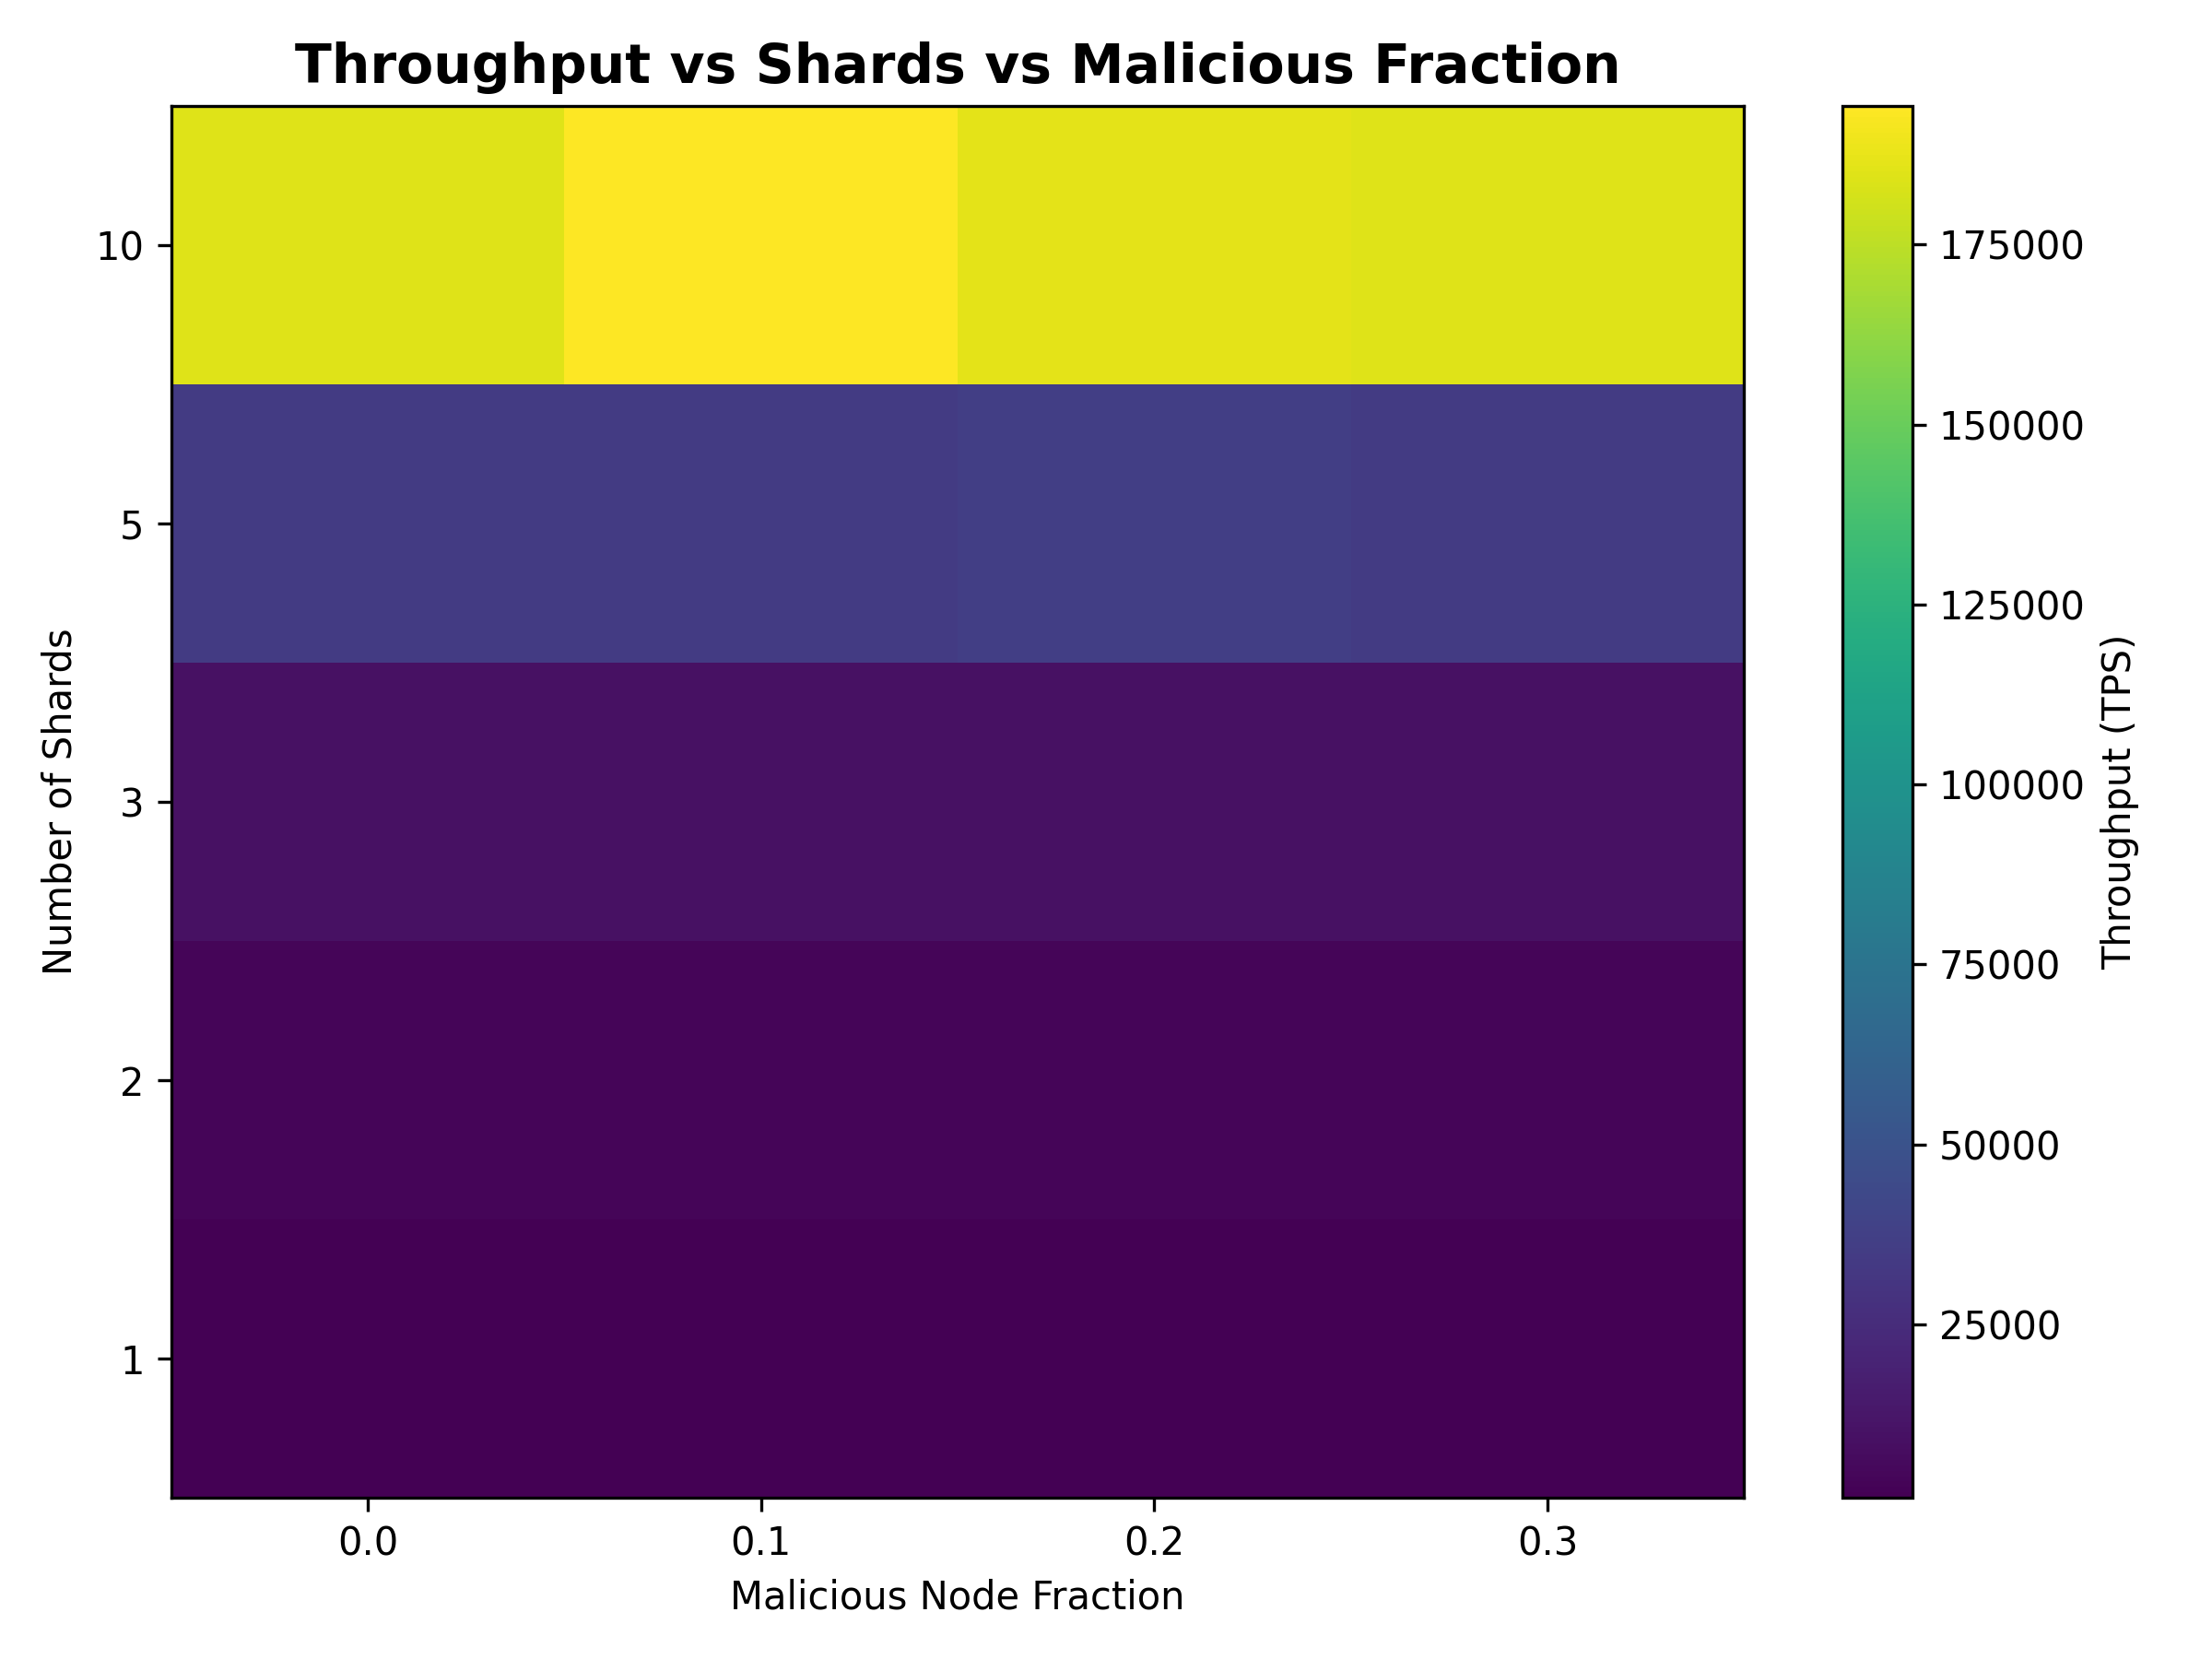


--- latency_vs_malicious.png ---


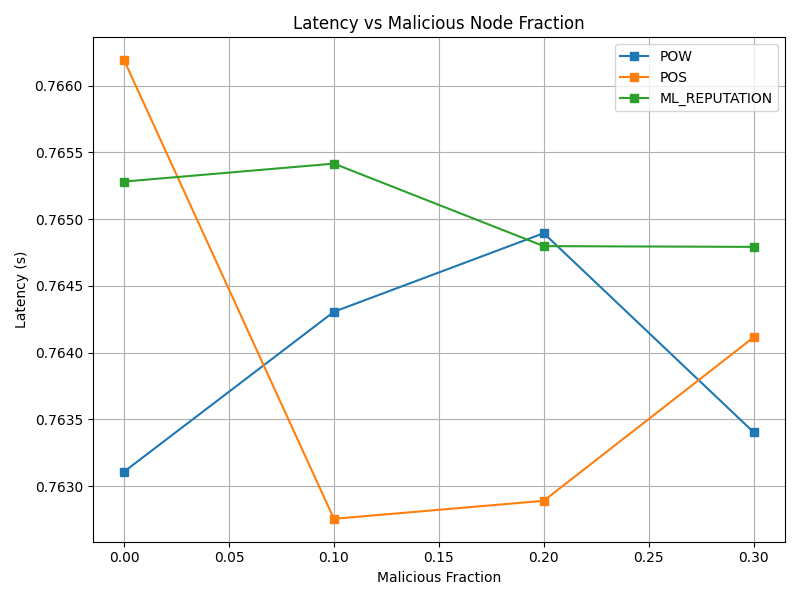


--- shard_performance.png ---


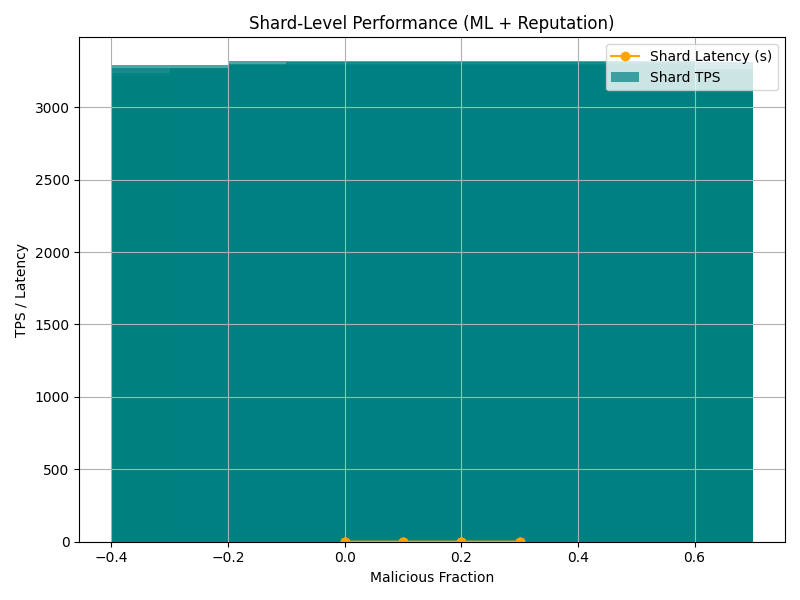


--- decentralization_vs_malicious.png ---


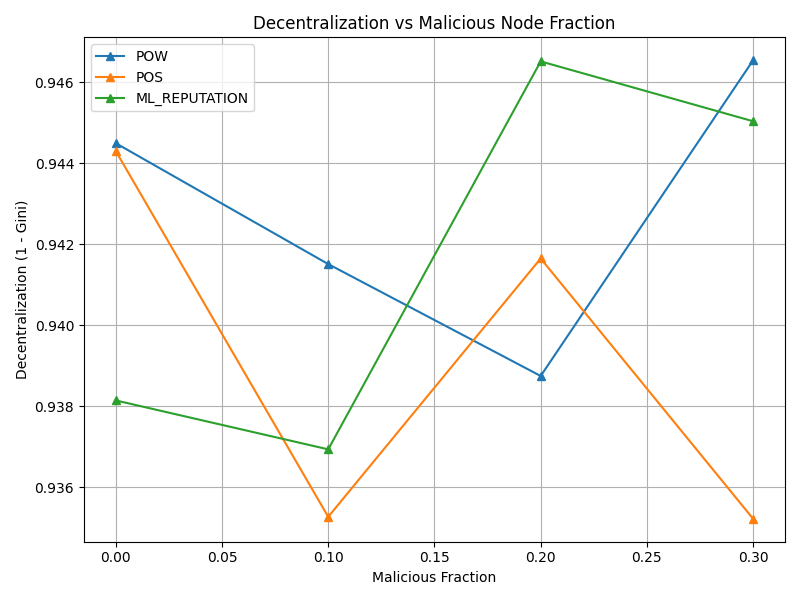


--- throughput_vs_malicious.png ---


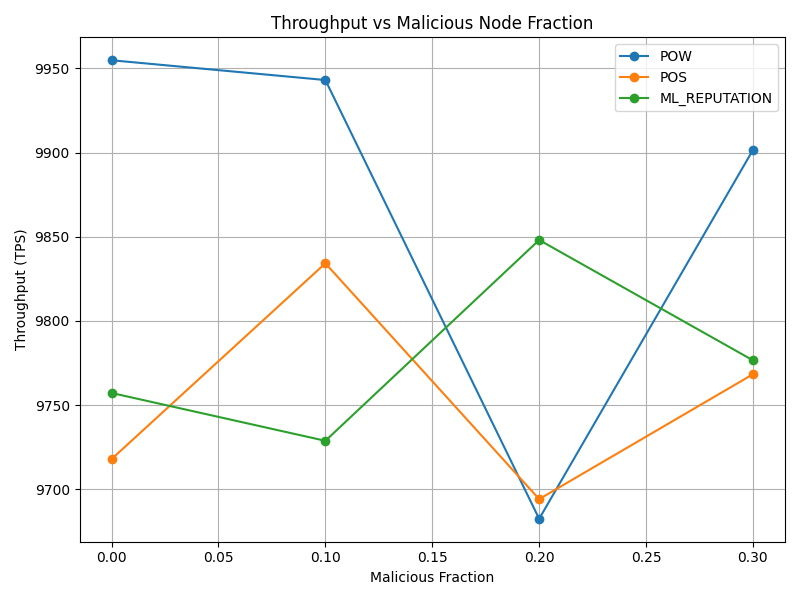


--- scalability_gain_vs_shards.png ---


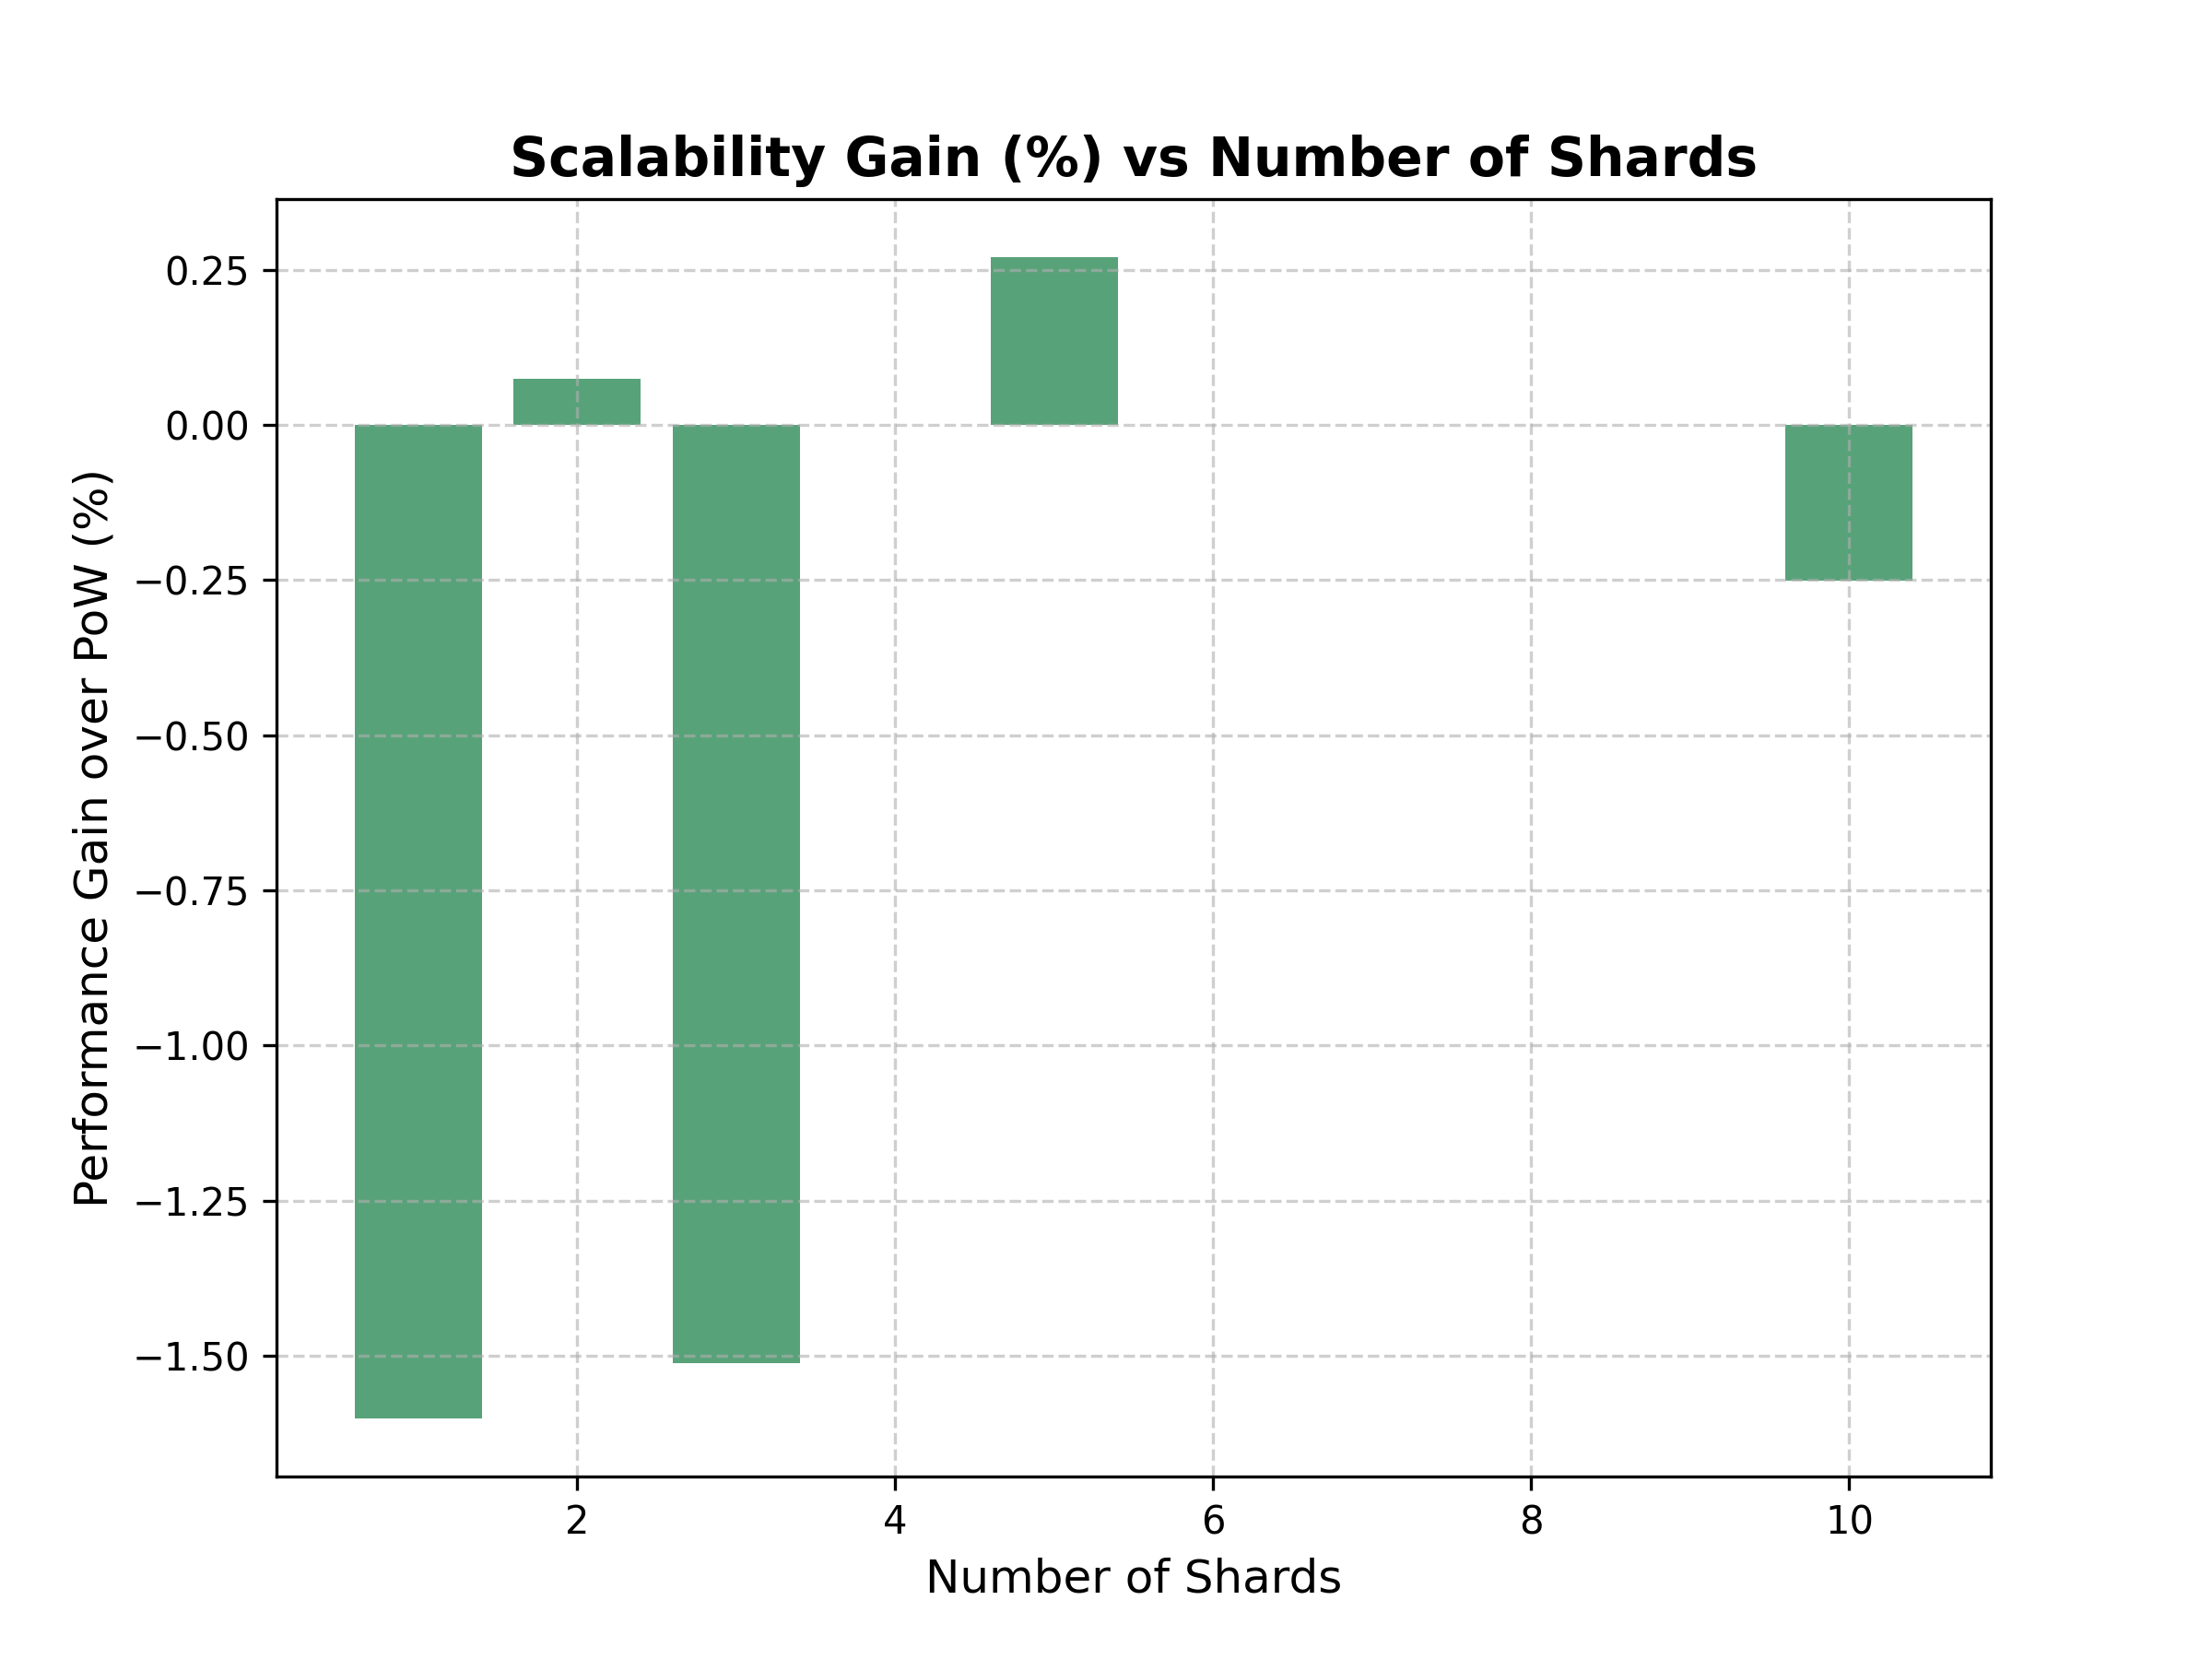


--- throughput_vs_shards.png ---


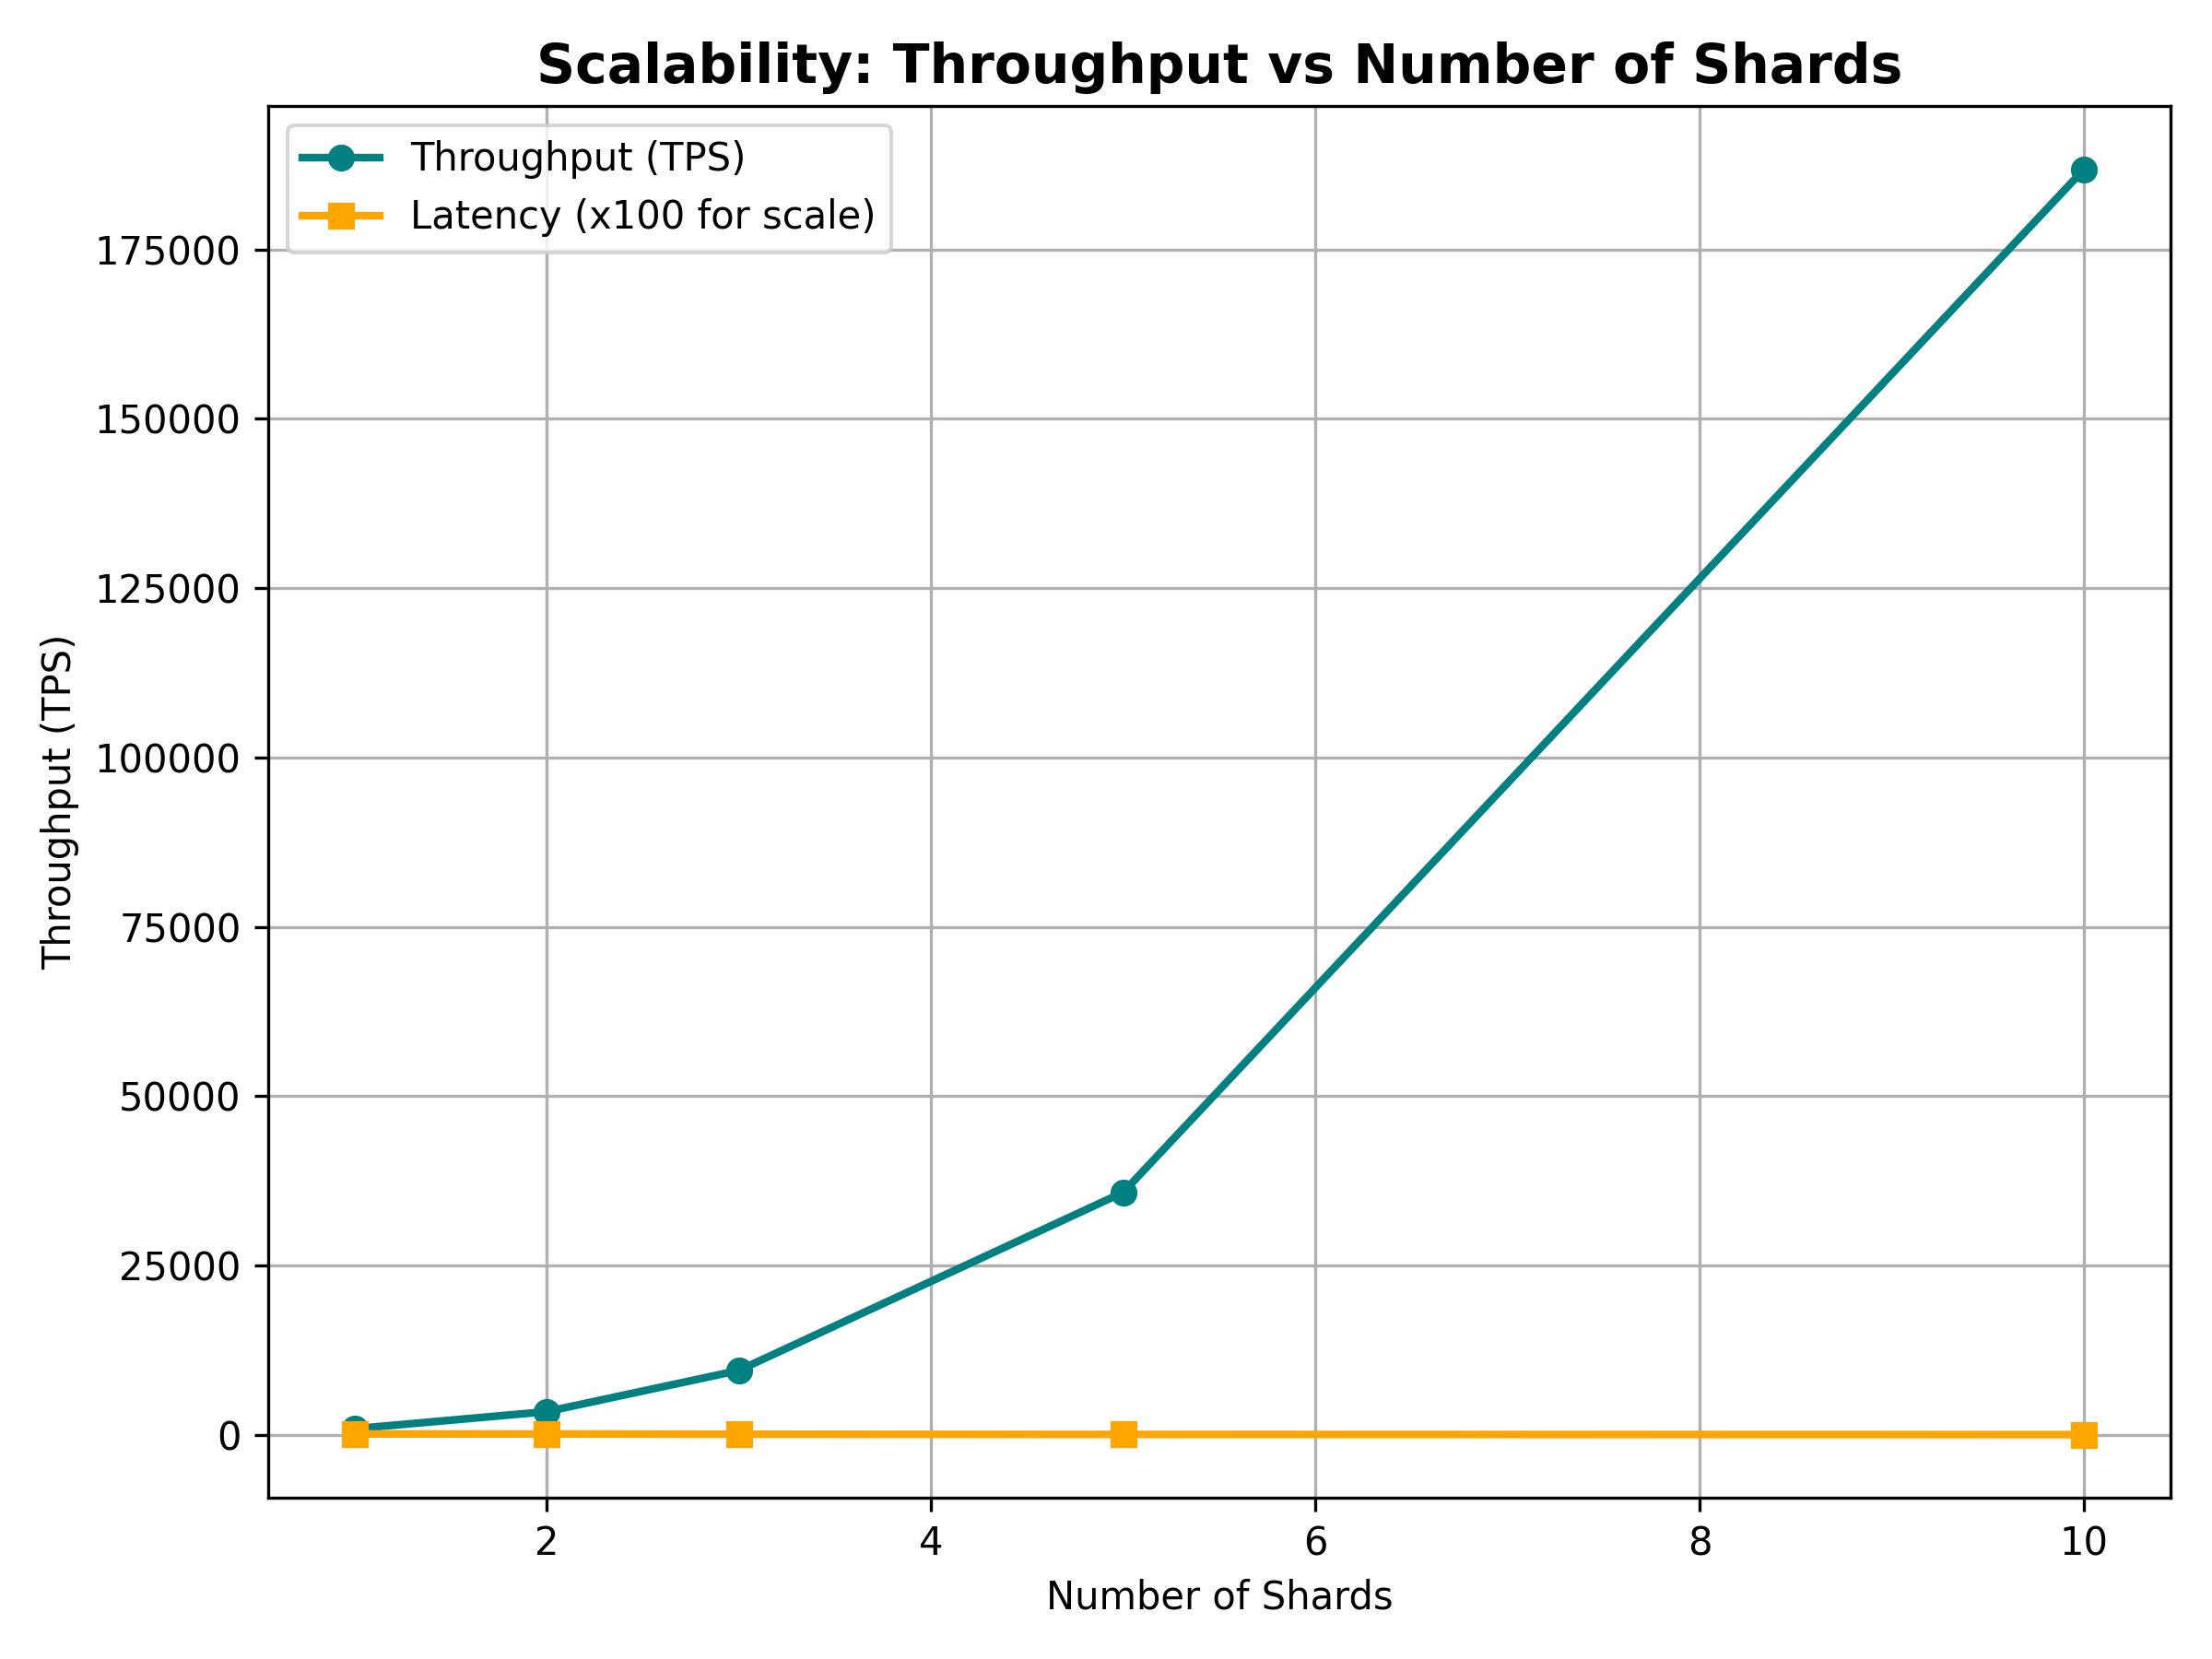


--- throughput_latency_pareto_heatmap.png ---


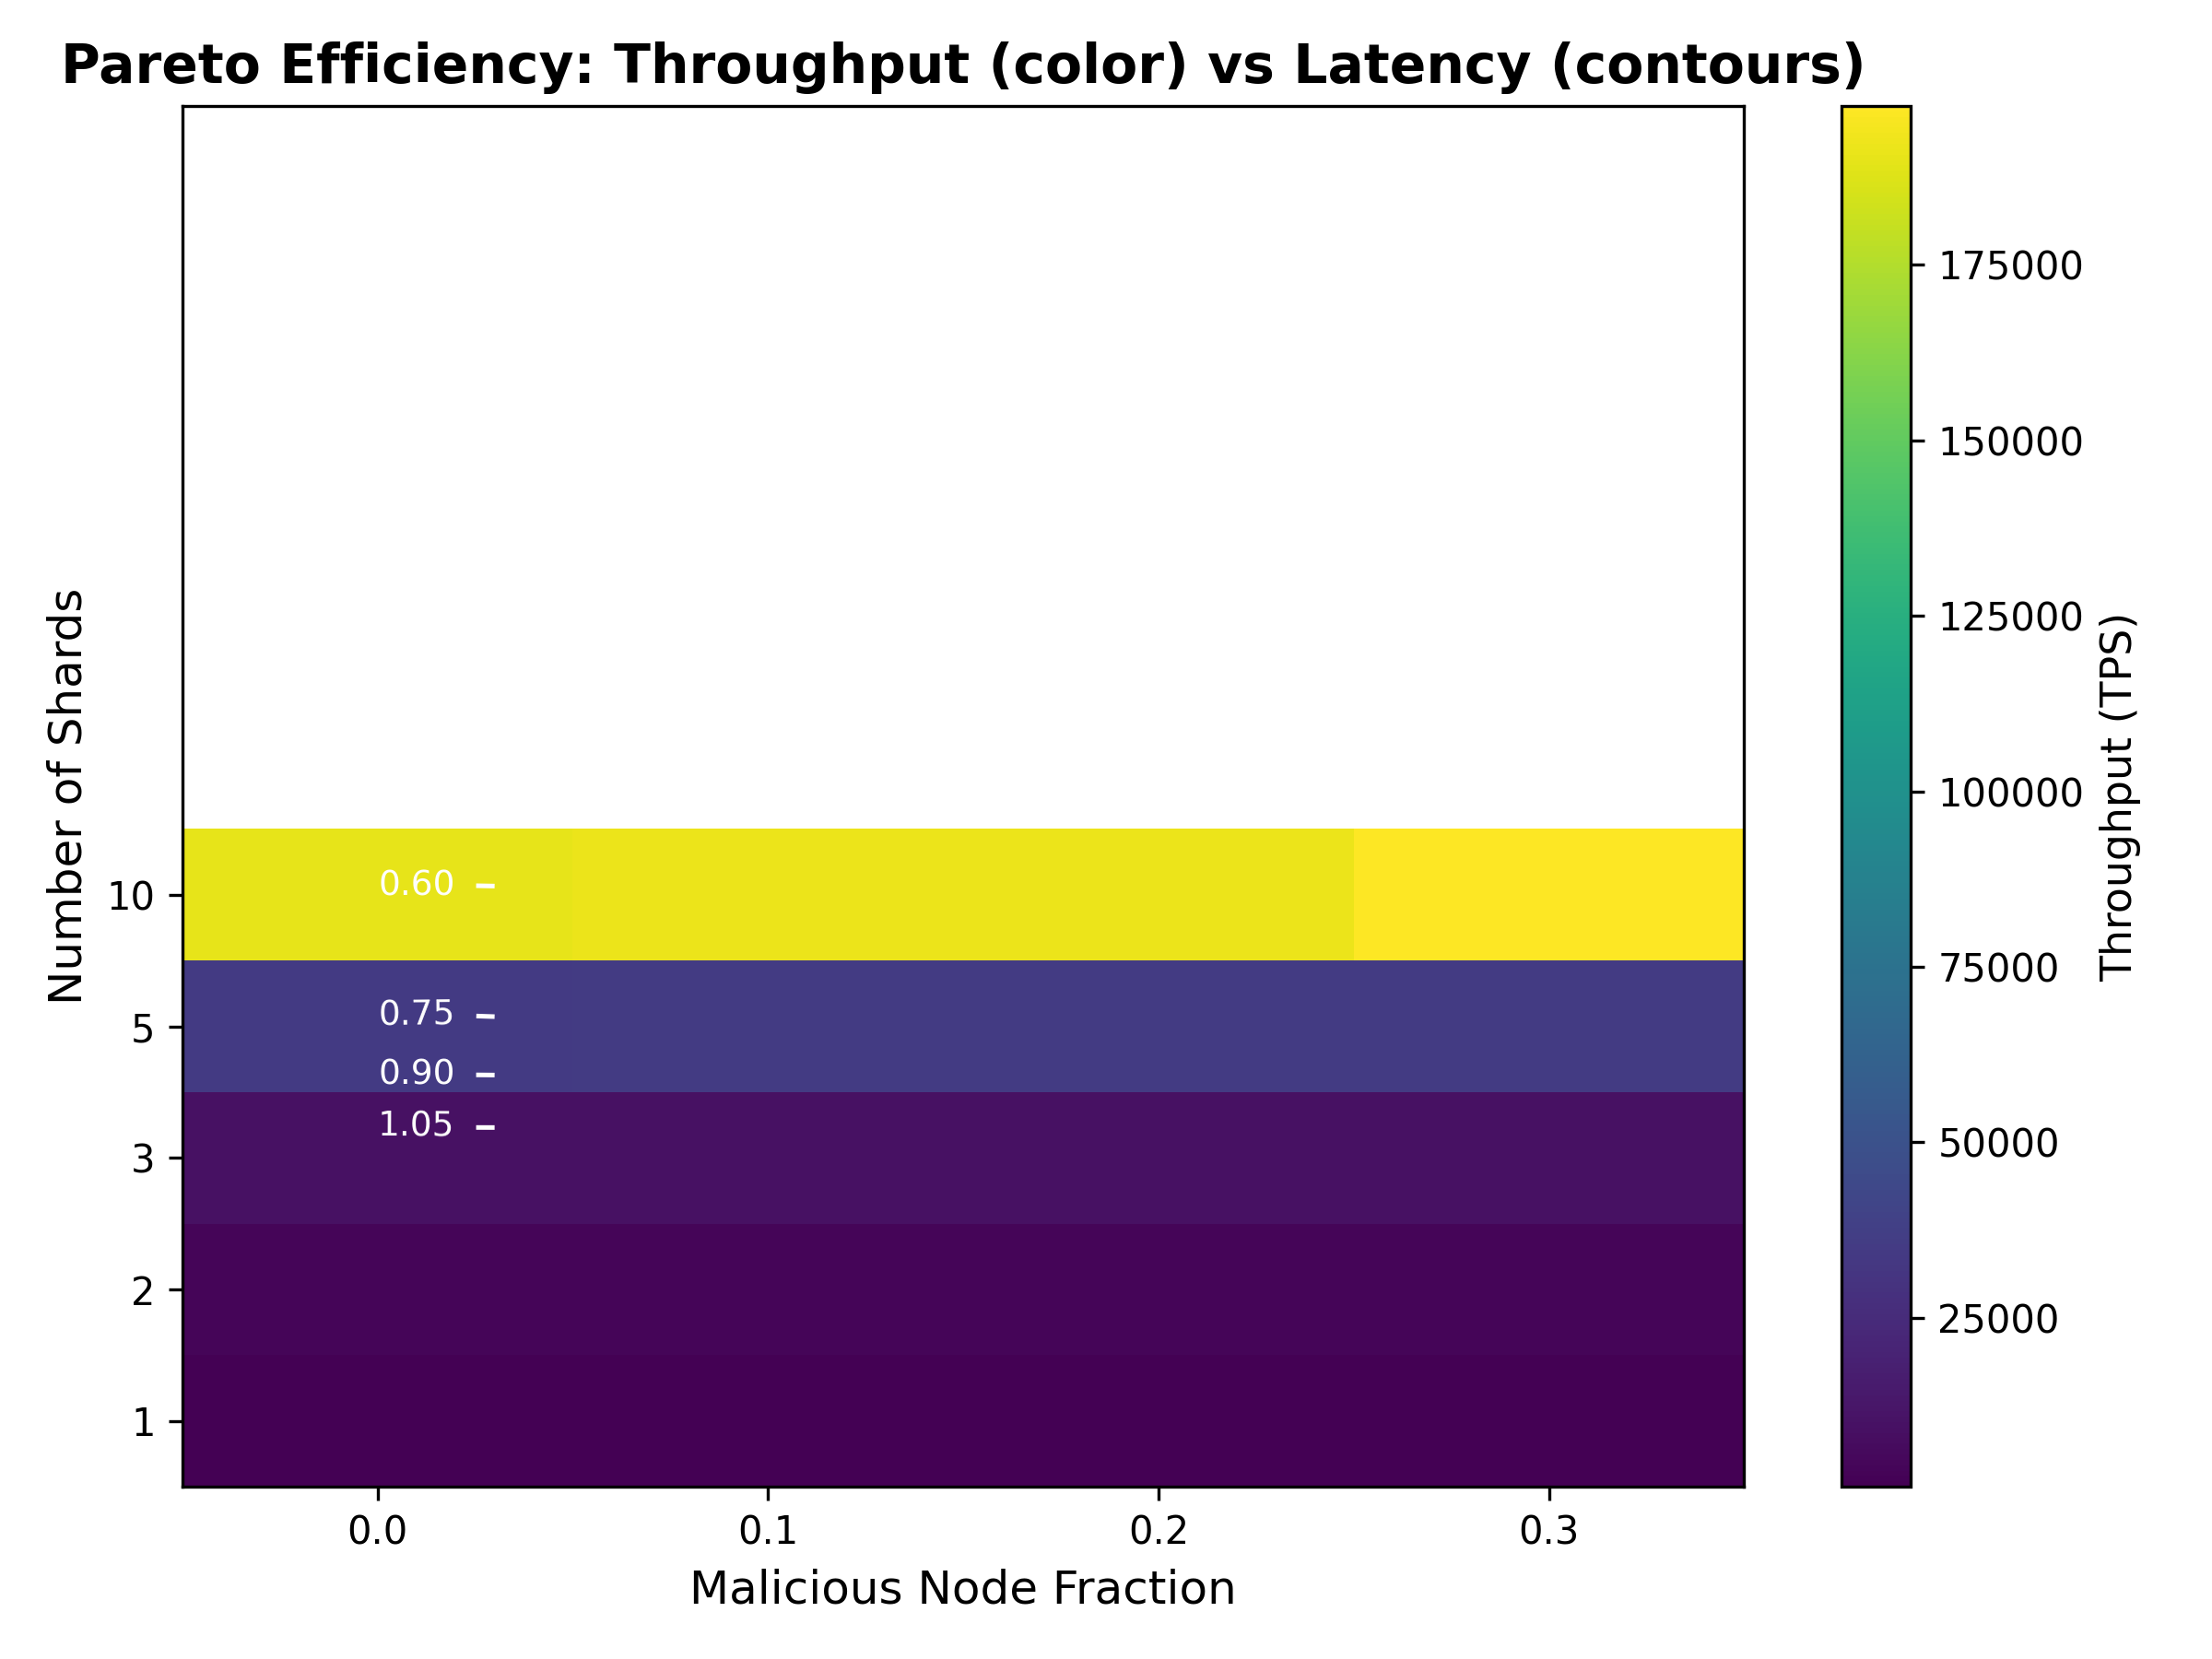

In [7]:
import os
from IPython.display import Image, display

# Directory containing the generated plots
plot_directory = "outputs_sharded_plot"

# Iterate through files in the directory and display image files
if os.path.exists(plot_directory):
    print(f"Displaying plots from '{plot_directory}':")
    for filename in os.listdir(plot_directory):
        if filename.endswith((".png", ".jpg", ".jpeg", ".gif")):
            filepath = os.path.join(plot_directory, filename)
            print(f"\n--- {filename} ---")
            display(Image(filename=filepath))
else:
    print(f"Plot directory '{plot_directory}' not found.")